In [13]:
import sys, os, importlib
package_path = os.path.abspath('../../')
if package_path not in sys.path:
    sys.path.append(package_path)
from package import functions as fn
from package import model as rm
from package import optimizer as opt
from package import plots
import numpy as np
import pandas as pd
import nbformat as nbf
from obspy.taup import TauPyModel
from obspy.geodetics import gps2dist_azimuth
from obspy.geodetics import kilometers2degrees
from obspy import read
from obspy import Stream
from matplotlib import pyplot as plt

from obspy.clients.fdsn import Client
from obspy import UTCDateTime
from obspy.signal.trigger import classic_sta_lta, trigger_onset
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

np.set_printoptions(precision=4, suppress=True)
for module in [fn, rm, opt, plots]:
    importlib.reload(module)

# set seed for reproducibility
np.random.seed(2026)

In [14]:
def find_extrema_indices(arr):
    """
    Returns indices of local maxima and minima.
    """
    extrema = []
    
    for i in range(1, len(arr) - 1):
        if arr[i] > arr[i-1] and arr[i] > arr[i+1]:
            extrema.append(i)
        elif arr[i] < arr[i-1] and arr[i] < arr[i+1]:
            extrema.append(i)
    
    return extrema


def average_half_period(arr):
    """
    Computes average spacing between consecutive extrema.
    This corresponds to average half-period.
    """
    extrema = find_extrema_indices(arr)
    
    if len(extrema) < 2:
        raise ValueError("Not enough extrema to compute half-period.")
    
    spacings = [extrema[i+1] - extrema[i] for i in range(len(extrema)-1)]
    
    return sum(spacings) / len(spacings)


def get_p_polarity(stream, p_inc, p_delay=300, window_size=60, stretch=None,
                   displacement=0, return_aic=False):
    # given one trace, get p wave polarity
    # use one loc per station for now
    
    baz = stream[0].stats.sac.baz
    p_init = stream[0].stats.starttime
    p_arrival = p_init + p_delay
    p_start = p_arrival - window_size + displacement
    p_end = p_arrival + window_size + displacement
    delta = stream[0].stats.delta
    
    data = np.zeros((len(stream), len(stream[0].data)))
    tr_ZL = stream.select(component='Z')[0].copy()
    tr_NQ = stream.select(component='N')[0].copy()
    tr_ET = stream.select(component='E')[0].copy()
    
    
    for tr in [tr_ZL, tr_NQ, tr_ET]: # IMPORTANT
        tr.detrend('linear')
        tr.detrend('demean')
        tr.filter('lowpass', freq=.1, corners=4,
                  zerophase=False)
    
    data[0, :] = tr_ZL.data
    data[1, :] = tr_NQ.data
    data[2, :] = tr_ET.data
    
    R_zne2zrt = fn.zne2zrt_matrix(baz, deg=True)
    R_zrt2lqt = fn.zrt2lqt_matrix(p_inc=p_inc, deg=True)
    data_lqt = R_zrt2lqt @ R_zne2zrt @ data
    
    pol_data = data_lqt[0, :]
    p_start_idx = int((p_start - p_init) / delta)
    p_end_idx = int((p_end - p_init) / delta)
    pol_window = pol_data[p_start_idx:p_end_idx+1]
    scale = 1/np.mean(np.abs(pol_window))
    aic_values = fn.aic(scale * pol_window)
    min_aic_idx = np.argmin(aic_values)
    
    if stretch is None:
        quarter_period = average_half_period(pol_window)/2
        stretch = int(quarter_period)
    
    zoom_pol_data = pol_window[min_aic_idx:min_aic_idx+stretch]
    diffs = scale * np.diff(zoom_pol_data)
    signs = np.sign(diffs)
    p_polarity = np.sign(np.sum(signs))
    
    if return_aic:
        return p_polarity, aic_values
    return p_polarity

In [15]:
# data_path = '../../data/2021-10-10-ml62-hawaii-big'
# data_path = '../../data/2011-01-01-mw70-santiago-del-estero-prov-arg-big'
# data_path = '../../data/2020-12-29-mww64-northwestern-balkan-region-big'
# data_path = '../../data/2005-03-28-mw86-northern-sumatra-indonesia-big'
data_path = '../../data/1994-01-17-mw67-southern-california'
files = [f for f in os.listdir(data_path) if f.endswith('.SAC')]
streams = [read(data_path + '/' + f) for f in files]
locs = {st[0].stats.location for st in streams}
print(locs)

{'', '00'}


In [16]:
# data preprocessing
# traces = [st[0] for st in streams if st[0].stats.location == '00']
traces = [st[0] for st in streams if st[0].stats.location == '00'
          or st[0].stats.location == '']
traces_dict = defaultdict(list)
for tr in traces: traces_dict[tr.stats.station].append(tr)

for station in list(traces_dict.keys()):
    if len(traces_dict[station]) != 3: del traces_dict[station]
    #  special stations
    if station == 'ALE':
        print(f'Buggy station {station}')
        del traces_dict[station]

station_count = 0
for name in traces_dict:
    station_count += 1
    if len(traces_dict[name]) != 3:
        print(f"Station {name} has {len(traces_dict[name])} trace(s).")
print(f'Total stations: {station_count}')

# # NOTE: hawaii
# eq_lat = 18.820333
# eq_lon = -155.527167
# hdepth = 35.06

# # NOTE: santiago
# eq_lat = -26.8513
# eq_lon = -63.2373
# hdepth = 584.3

# # NOTE: balkan
# eq_lat = 42.425
# eq_lon = 16.2581
# hdepth = 10.0

# # NOTE: sumatra
# eq_lat = 2.0964
# eq_lon = 97.1131
# hdepth = 30.0

# NOTE: northridge
eq_lat = 34.136
eq_lon = -118.5826
hdepth = 15.9

velocity_model = TauPyModel(model='ak135')
vel_model_path = '../../data/AK135_lookup.csv'
lookup_table = pd.read_csv(vel_model_path)

alpha, beta = fn.extract_velocities(lookup_table, hdepth)
print(f'At depth {hdepth} km, P velocity = {alpha} km/s, S velocity = {beta} km/s')

Buggy station ALE
Total stations: 42
At depth 15.9 km, P velocity = 5.8 km/s, S velocity = 3.46 km/s


Processing station XAN...
Processing station ARU...
Processing station TATO...
Processing station LVZ...
Processing station COR...
Processing station SPA...
Station SPA has no P arrival. Skipping.
Epidist = 123.94 degrees
Processing station VNDA...
Station VNDA has no P arrival. Skipping.
Epidist = 120.82 degrees
Processing station NWAO...
Station NWAO has no P arrival. Skipping.
Epidist = 134.05 degrees
Processing station AFI...
Processing station PMG...
Count = 10 for station PMG
Processing station PMSA...
Station PMSA has no P arrival. Skipping.
Epidist = 107.39 degrees
Processing station LBTB...
Station LBTB has no P arrival. Skipping.
Epidist = 147.78 degrees
Processing station ERM...
Processing station KEV...
Processing station SJG...
Processing station RPN...
Processing station YSS...
Processing station TAU...
Station TAU has no P arrival. Skipping.
Epidist = 115.06 degrees
Processing station ABKT...
Station ABKT has no P arrival. Skipping.
Epidist = 108.08 degrees
Processing st

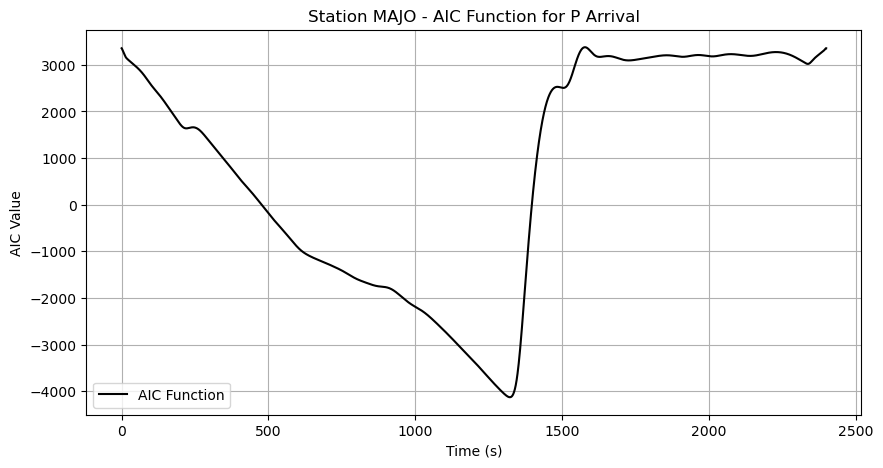

In [17]:
col_string = 'event_id, station, network, location, channel, p_polarity, takeoff, takeoff_uncertainty, azimuth, azimuth_uncertainty'
columns = [col.strip() for col in col_string.split(',')]
df = pd.DataFrame(columns=columns)
event_id = 1
takeoff_uncertainty = 0.1 # placeholder
azimuth_uncertainty = 0.1 # placeholder
pre_filt = (0.01, 0.02, 8.0, 10.0)
aic_dict = {}
name_solid = None
count = 0

for name in traces_dict:
    count += 1
    # if count < 30: continue
    print(f"Processing station {name}...")
    if count % 10 == 0:
        print(f"Count = {count} for station {name}")
    stream = Stream(traces_dict[name])
    station = stream[0].stats.station
    network = stream[0].stats.network
    
    client = Client("IRIS")
    starttime = stream[0].stats.starttime
    endtime = stream[0].stats.endtime
    inv = client.get_stations(network=network, station=name,
                        starttime=starttime, endtime=endtime,
                        level='response')
    
    for trace in stream:
        trace.remove_response(inventory=inv, output="DISP", pre_filt=pre_filt,
                        plot=False, water_level=None)
    
    stream._rotate_to_zne(inventory=inv)
    
    # rotate the stream to ZNE
    location = stream[0].stats.location
    channel = stream[0].stats.channel
    azimuth = stream[0].stats.sac.az
    sta_lat = stream[0].stats.sac.stla
    sta_lon = stream[0].stats.sac.stlo
    event_locs = [eq_lat, eq_lon, sta_lat, sta_lon]
    dist, az_check, baz_check = gps2dist_azimuth(*event_locs)
    epdist = kilometers2degrees(dist/1000)
    p_arrivals = velocity_model.get_travel_times(source_depth_in_km=hdepth,
                        distance_in_degree=epdist, phase_list=['P'])
    
    if len(p_arrivals) == 0:
        print(f"Station {station} has no P arrival. Skipping.")
        print(f"Epidist = {epdist:.2f} degrees")
        continue
    
    takeoff = p_arrivals[0].takeoff_angle
    takeoff = 180 - takeoff # < 90 up convention for SKHASH
    
    p_arrival = p_arrivals[0]
    p_inc = p_arrival.incident_angle
    p_polarity, aic = get_p_polarity(stream=stream, p_inc=p_inc,
                                window_size=60, stretch=50, return_aic=True)
    aic_dict[station] = aic
    
    name_solid = name
    
    # now add row to pandas
    # p_polarity = -p_polarity # reverse to see NOTE reversing makes it good
    df.loc[len(df)] = [event_id, station, network, location, channel, p_polarity,
                       takeoff, takeoff_uncertainty, azimuth, azimuth_uncertainty]
    
    # if count == 200:
    #     print(f'Stopping here')
    #     break


to_plot = aic_dict[name_solid]
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(np.arange(len(to_plot)), to_plot, 'k', label='AIC Function')
ax.set_xlabel('Time (s)')
ax.set_ylabel('AIC Value')
ax.set_title(f'Station {name_solid} - AIC Function for P Arrival')
ax.legend()
ax.grid()
plt.show()

In [18]:
df.to_csv('pol.csv', index=False)

In [19]:
# # change the values in p_polarity to negative
# df['p_polarity'] = -df['p_polarity']

In [20]:
# df
# # filter to remain with these:
# # ADK, TLY, SSE, KURK, KAPI, COLA, ERM, INCN, KEV
# # HIA, PET, MA2, MAJO, KBS, KDAK, YSS, ULN

# my_list = ['ADK', 'TLY', 'SSE', 'KURK', 'KAPI', 'COLA', 'ERM', 'INCN', 'KEV',
#         'HIA', 'PET', 'MA2', 'MAJO', 'KBS', 'KDAK', 'YSS', 'ULN']
# df_filt = df[df['station'].isin(my_list)]

# df_filt.to_csv('pol_filt_max.csv', index=False)

In [21]:
# # save df as csv
# # first check the directory we're in
# print(os.getcwd())
# # save to cwd, call it pol.csv
# df.to_csv('pol.csv', index=False)

In [22]:
# # get p_polarity for station KEV
# kev_pol = df[df['station'] == 'KEV']['p_polarity'].values[0]
# print(f"P-wave polarity for station KEV: {kev_pol}")

In [23]:
df


,event_id,station,network,location,channel,p_polarity,takeoff,takeoff_uncertainty,azimuth,azimuth_uncertainty
0,1,XAN,IC,,BHE,1.0,166.478080,0.1,321.701904,0.1
1,1,ARU,II,00,BHZ,1.0,165.912113,0.1,1.585546,0.1
2,1,TATO,IU,,BHE,1.0,166.409723,0.1,307.386841,0.1
3,1,LVZ,II,00,BHN,1.0,162.708115,0.1,10.102750,0.1
4,1,COR,IU,,BHN,1.0,134.301915,0.1,342.133575,0.1
5,1,AFI,IU,,BHE,1.0,161.184274,0.1,236.072601,0.1
6,1,PMG,IU,,BHN,1.0,166.477586,0.1,264.558533,0.1
7,1,ERM,II,00,BHZ,1.0,162.070061,0.1,309.730164,0.1
8,1,KEV,IU,,BHZ,1.0,162.030271,0.1,11.844385,0.1
9,1,SJG,IU,,BHE,1.0,156.418160,0.1,95.127518,0.1


In [24]:
# df

# # filter azimuth between 0-100 and 150-300
# # df_180 = df[(df['azimuth'] >= 0) & (df['azimuth'] <= 100) | (df['azimuth'] >= 150) & (df['azimuth'] <= 300)]
# df_180 = df[(df['azimuth'] >= 300) & (df['azimuth'] <= 360)]

# # filter takeoff to be between 15 and 45
# df_takeoff = df_180[(df_180['takeoff'] >= 0) & (df_180['takeoff'] <= 20)]
# df_takeoff

In [25]:
# # print stations of filtered df
# print("Stations in filtered dataframe:")
# print(df_takeoff['station'])

In [26]:
# df_takeoff.to_csv('pol_misclass.csv', index=False)

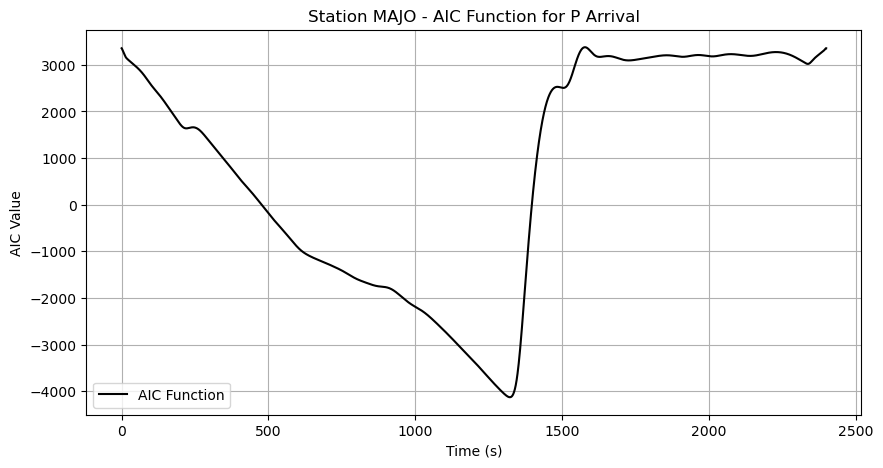

In [27]:
# name_test = 'KEV'
name_test = name_solid
to_plot = aic_dict[name_test]
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(np.arange(len(to_plot)), to_plot, 'k', label='AIC Function')
ax.set_xlabel('Time (s)')
ax.set_ylabel('AIC Value')
ax.set_title(f'Station {name_test} - AIC Function for P Arrival')
ax.legend()
ax.grid()
plt.show()